STEP 1: Loading and merging datasets
  df1 shape      : (525461, 8)
  df2 shape      : (541910, 8)
  Merged shape   : (1067371, 8)
  Columns        : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

STEP 2: Preprocessing
  Dropped duplicates     : 34335 rows
  Dropped null CustomerID: 235151 rows
  Dropped returns (Qty<0): 18390 rows
  Dropped zero price     : 70 rows

  Final clean shape  : (779425, 9)
  Unique customers   : 5878
  Date range         : 2009-12-01 → 2011-12-09
  Null check         : 0 nulls remaining

STEP 3: Feature Engineering
  Snapshot date: 2011-12-10

  Feature table shape: (5878, 7)

  Feature summary:
       Recency  Frequency       AOV   Tenure  TotalOrders        LTV
count  5878.00    5878.00   5878.00  5878.00      5878.00    5878.00
mean    201.33       6.29     48.30   273.02         6.29    2955.90
std     209.34      13.01    780.18   258.81        13.01   14440.85
min       1.00       1.00      

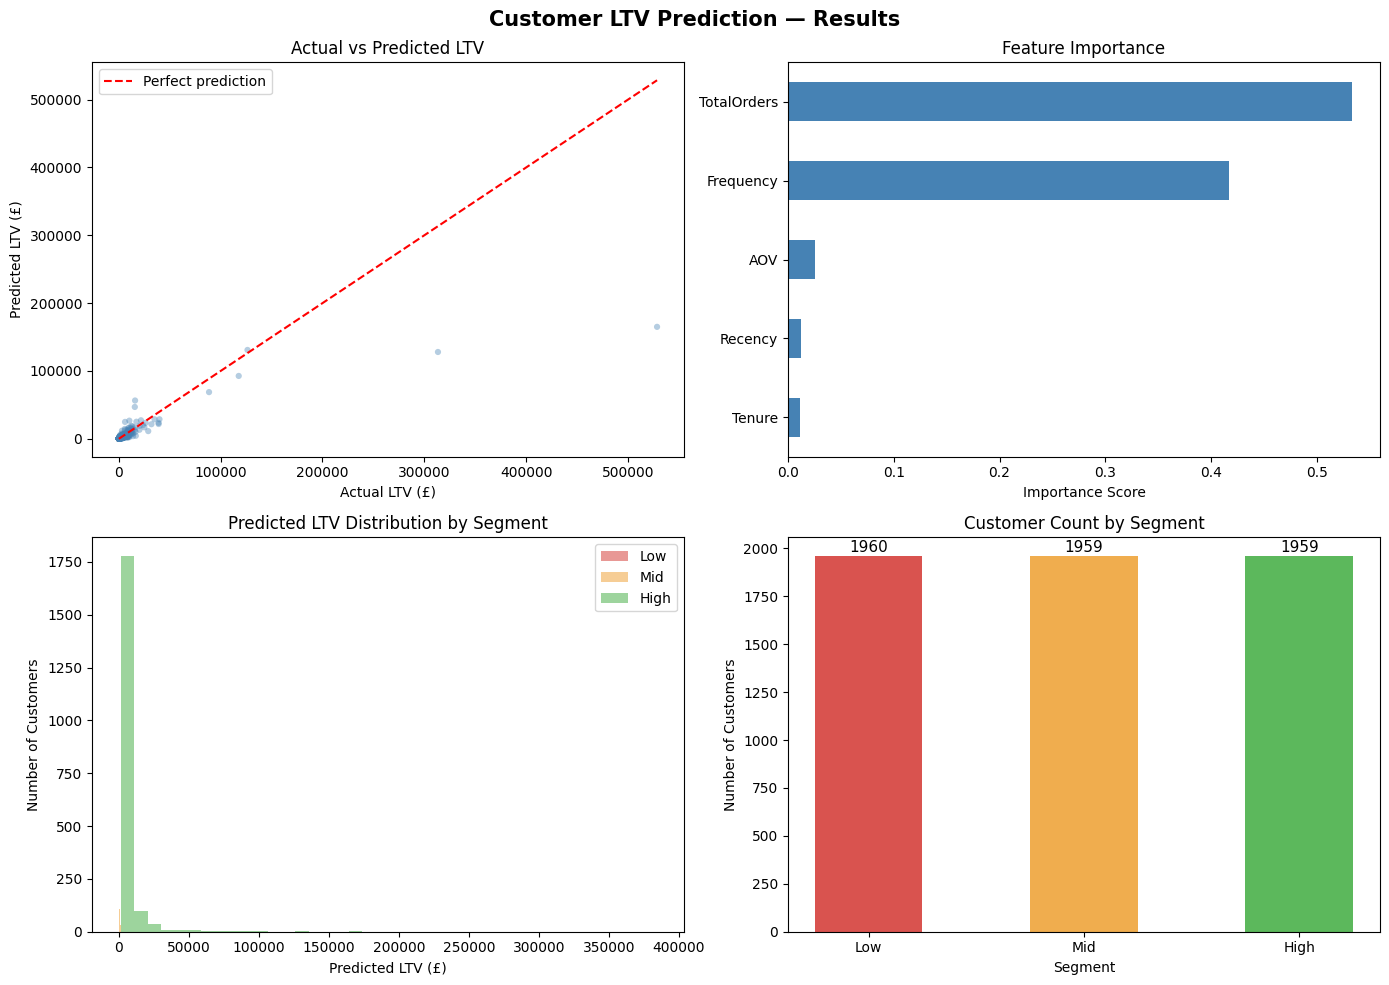


ALL STEPS COMPLETE
  Outputs:
    → ltv_predictions.csv
    → ltv_visualizations.png


In [16]:
"""
Customer Lifetime Value (LTV) Prediction
-----------------------------------------
Requirements:
    pip install pandas numpy scikit-learn xgboost matplotlib seaborn

Usage:
    Place both CSV files in the same folder as this script, then run:
    python ltv_prediction_full.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────
# STEP 1: Load & Merge
# ─────────────────────────────────────────────
print("=" * 55)
print("STEP 1: Loading and merging datasets")
print("=" * 55)

df1 = pd.read_csv("online_retail_09_10.csv", encoding='utf-8', on_bad_lines='skip')
df2 = pd.read_csv("online_retail_10_11.csv", encoding='utf-8', on_bad_lines='skip')
df  = pd.concat([df1, df2], ignore_index=True)

print(f"  df1 shape      : {df1.shape}")
print(f"  df2 shape      : {df2.shape}")
print(f"  Merged shape   : {df.shape}")
print(f"  Columns        : {list(df.columns)}")


# ─────────────────────────────────────────────
# STEP 2: Preprocessing
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 2: Preprocessing")
print("=" * 55)

before = len(df)
df.drop_duplicates(inplace=True)
print(f"  Dropped duplicates     : {before - len(df)} rows")

before = len(df)
df.dropna(subset=['CustomerID'], inplace=True)
print(f"  Dropped null CustomerID: {before - len(df)} rows")

before = len(df)
df = df[df['Quantity'] > 0]
print(f"  Dropped returns (Qty<0): {before - len(df)} rows")

before = len(df)
df = df[df['UnitPrice'] > 0]
print(f"  Dropped zero price     : {before - len(df)} rows")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue']     = df['Quantity'] * df['UnitPrice']

print(f"\n  Final clean shape  : {df.shape}")
print(f"  Unique customers   : {df['CustomerID'].nunique()}")
print(f"  Date range         : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"  Null check         : {df.isnull().sum().sum()} nulls remaining")


# ─────────────────────────────────────────────
# STEP 3: Feature Engineering
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 3: Feature Engineering")
print("=" * 55)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"  Snapshot date: {snapshot_date.date()}")

features = df.groupby('CustomerID').agg(
    Recency     = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency   = ('InvoiceNo',   'nunique'),
    AOV         = ('Revenue',     lambda x: x.sum() / x.count()),
    Tenure      = ('InvoiceDate', lambda x: (x.max() - x.min()).days),
    TotalOrders = ('InvoiceNo',   'nunique'),
    LTV         = ('Revenue',     'sum')
).reset_index()

print(f"\n  Feature table shape: {features.shape}")
print(f"\n  Feature summary:")
print(features[['Recency','Frequency','AOV','Tenure','TotalOrders','LTV']].describe().round(2).to_string())


# ─────────────────────────────────────────────
# STEP 4: Model Training
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 4: Model Training (XGBoost)")
print("=" * 55)

features['LTV_log'] = np.log1p(features['LTV'])

X = features[['Recency', 'Frequency', 'AOV', 'Tenure', 'TotalOrders']]
y = features['LTV_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"  Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
print("  Model trained successfully.")


# ─────────────────────────────────────────────
# STEP 5: Evaluate — MAE, RMSE, R²
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 5: Evaluation")
print("=" * 55)

y_pred_log = model.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_actual   = np.expm1(y_test)

mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2   = r2_score(y_actual, y_pred)
cv   = cross_val_score(model, X, y, cv=5, scoring='r2')

print(f"  MAE            : £{mae:,.2f}")
print(f"  RMSE           : £{rmse:,.2f}")
print(f"  R² (test set)  : {r2:.4f}")
print(f"  R² (5-fold CV) : {cv.mean():.4f} ± {cv.std():.4f}")

print("\n  Feature importances:")
for feat, imp in sorted(zip(X.columns, model.feature_importances_), key=lambda x: -x[1]):
    bar = "█" * int(imp * 50)
    print(f"    {feat:<12}: {imp:.4f}  {bar}")


# ─────────────────────────────────────────────
# STEP 6: Segment + Export CSV
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 6: Segmentation + Export")
print("=" * 55)

features['Predicted_LTV'] = np.expm1(model.predict(X))

features['Segment'] = pd.qcut(
    features['Predicted_LTV'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

summary = features.groupby('Segment')['Predicted_LTV'].agg(['count','min','max','mean']).round(2)
summary.columns = ['Count', 'Min £', 'Max £', 'Avg £']
print("\n  Segment breakdown:")
print(summary.to_string())

output_cols = [
    'CustomerID', 'Recency', 'Frequency', 'AOV',
    'Tenure', 'TotalOrders', 'LTV', 'Predicted_LTV', 'Segment'
]
output = features[output_cols]
output.to_csv("ltv_predictions.csv", index=False)
print(f"\n  ✓ ltv_predictions.csv saved — {output.shape[0]} customers, {output.shape[1]} columns")


# ─────────────────────────────────────────────
# VISUALIZATIONS
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Generating visualizations...")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Customer LTV Prediction — Results", fontsize=15, fontweight='bold')

# 1. Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_actual, y_pred, alpha=0.4, color='steelblue', edgecolors='none', s=20)
max_val = max(y_actual.max(), y_pred.max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel("Actual LTV (£)")
ax1.set_ylabel("Predicted LTV (£)")
ax1.set_title("Actual vs Predicted LTV")
ax1.legend()

# 2. Feature Importance
ax2 = axes[0, 1]
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title("Feature Importance")
ax2.set_xlabel("Importance Score")

# 3. LTV Distribution by Segment
ax3 = axes[1, 0]
colors = {'Low': '#d9534f', 'Mid': '#f0ad4e', 'High': '#5cb85c'}
for seg in ['Low', 'Mid', 'High']:
    subset = features[features['Segment'] == seg]['Predicted_LTV']
    ax3.hist(subset, bins=40, alpha=0.6, label=seg, color=colors[seg])
ax3.set_xlabel("Predicted LTV (£)")
ax3.set_ylabel("Number of Customers")
ax3.set_title("Predicted LTV Distribution by Segment")
ax3.legend()

# 4. Customer count per Segment
ax4 = axes[1, 1]
seg_counts = features['Segment'].value_counts().reindex(['Low', 'Mid', 'High'])
bars = ax4.bar(seg_counts.index, seg_counts.values,
               color=[colors[s] for s in seg_counts.index], width=0.5)
ax4.set_title("Customer Count by Segment")
ax4.set_xlabel("Segment")
ax4.set_ylabel("Number of Customers")
for bar, val in zip(bars, seg_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("ltv_visualizations.png", dpi=150, bbox_inches='tight')
print("  ✓ ltv_visualizations.png saved")

plt.show()

print("\n" + "=" * 55)
print("ALL STEPS COMPLETE")
print("  Outputs:")
print("    → ltv_predictions.csv")
print("    → ltv_visualizations.png")
print("=" * 55)